# Phishing Detection Multi-Model Comparison

This notebook trains multiple models on both datasets, compares metrics, selects the best model, and saves:
- saved_models/phishing_model.joblib
- saved_models/training_report.json

In [ ]:
import sys
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'joblib', 'pandas', 'scikit-learn', 'matplotlib'], check=True)

from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path
import json

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path('.').resolve()))

from train import (
    prepare_training_data,
    get_model_candidates,
    parse_requested_models,
    train_and_evaluate_models,
    rank_models,
)

EMAIL_PATH = Path('data/phishing_email.csv')
URL_PATH = Path('data/PhiUSIIL_Phishing_URL_Dataset.csv')
MODEL_OUT = Path('saved_models/phishing_model.joblib')
REPORT_OUT = Path('saved_models/training_report.json')
SELECTION_METRIC = 'phishing_f1'
RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_FEATURES = 100_000
MODELS = 'logistic_regression,linear_svc,calibrated_linear_svc,multinomial_nb,sgd_classifier,passive_aggressive'

In [2]:
df = prepare_training_data(email_path=EMAIL_PATH, url_path=URL_PATH)

x_train, x_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['label'],
)

model_builders = get_model_candidates(random_state=RANDOM_STATE, max_features=MAX_FEATURES)
requested_models = parse_requested_models(MODELS, model_builders)
results, fitted_models = train_and_evaluate_models(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    model_builders=model_builders,
    requested_models=requested_models,
)

ranked_results = rank_models(results, selection_metric=SELECTION_METRIC)
comparison_df = pd.DataFrame(ranked_results)
comparison_df[['name', 'accuracy', 'precision_phishing', 'recall_phishing', 'phishing_f1', 'macro_f1', 'weighted_f1', 'train_seconds', 'predict_seconds']]

KeyboardInterrupt: 

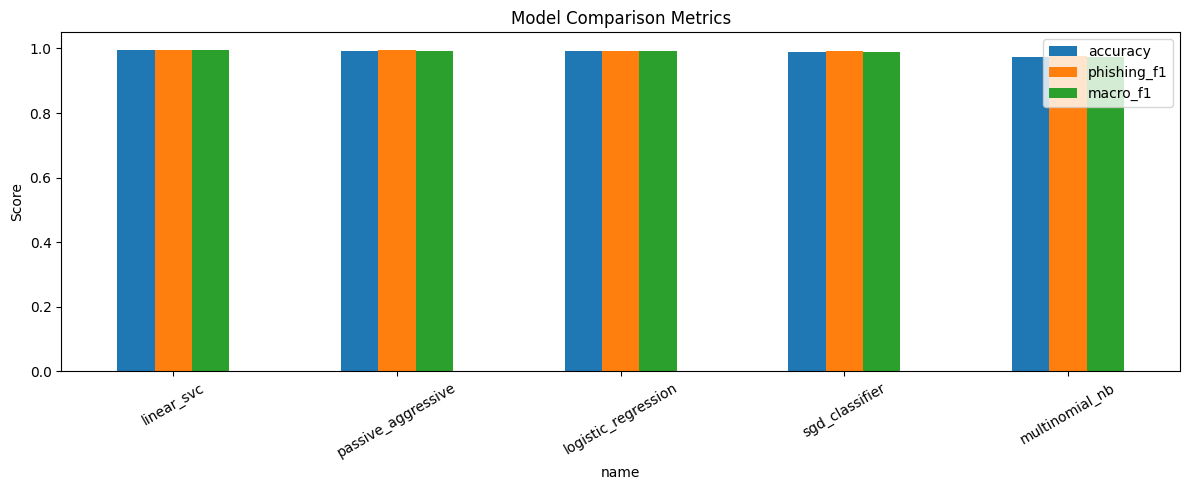

In [3]:
plot_df = comparison_df[['name', 'accuracy', 'phishing_f1', 'macro_f1']].set_index('name')
ax = plot_df.plot(kind='bar', figsize=(12, 5), rot=30)
ax.set_title('Model Comparison Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0.0, 1.05)
plt.tight_layout()
plt.show()

In [4]:
best_model_name = ranked_results[0]['name']
best_model = fitted_models[best_model_name]

MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
REPORT_OUT.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, MODEL_OUT)

training_report = {
    'timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'data': {
        'email_dataset': str(EMAIL_PATH),
        'url_dataset': str(URL_PATH),
        'rows_used': int(len(df)),
        'train_rows': int(len(x_train)),
        'test_rows': int(len(x_test)),
        'label_distribution': {
            'legitimate_0': int((df['label'] == 0).sum()),
            'phishing_1': int((df['label'] == 1).sum()),
        },
    },
    'selection': {
        'metric': SELECTION_METRIC,
        'best_model': best_model_name,
    },
    'models': ranked_results,
    'ranking': [row['name'] for row in ranked_results],
    'model_output': str(MODEL_OUT),
}

with REPORT_OUT.open('w', encoding='utf-8') as f:
    json.dump(training_report, f, indent=2)

print('Best model:', best_model_name)
print('Best score:', ranked_results[0][SELECTION_METRIC])
print('Saved model to:', MODEL_OUT)
print('Saved report to:', REPORT_OUT)

Best model: linear_svc
Best score: 0.9947207323579793
Saved model to: saved_models\phishing_model.joblib
Saved report to: saved_models\training_report.json


In [11]:
sample_inputs = [
    'https://cas$h-acadeva.xyz',
]

preds = best_model.predict(sample_inputs)
for text, pred in zip(sample_inputs, preds):
    print({'text': text, 'pred': int(pred)})

{'text': 'https://cas$h-acadeva.xyz', 'pred': 0}


## Additional Evaluation Visuals

These charts help compare model behavior beyond a single score:

- Dataset composition (labels + source)
- Per-model confusion matrices
- Training and prediction time comparison

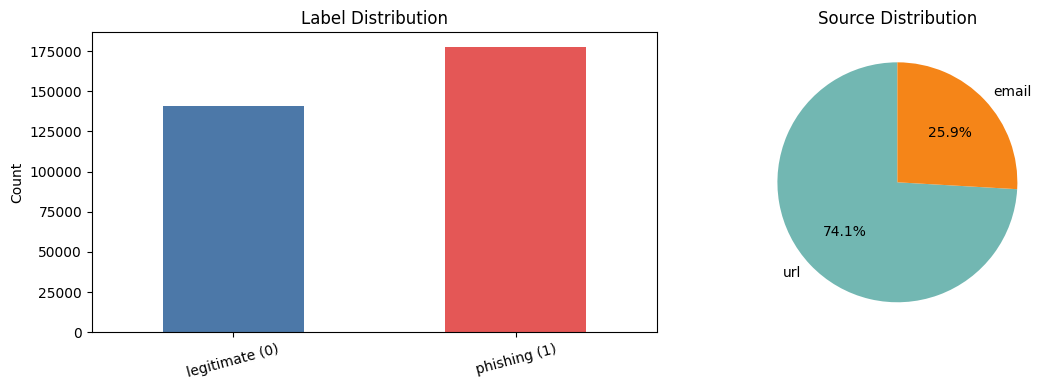

In [12]:
# Dataset composition visuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = df['label'].value_counts().sort_index()
label_counts.index = ['legitimate (0)', 'phishing (1)']
label_counts.plot(kind='bar', ax=axes[0], color=['#4C78A8', '#E45756'])
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

source_counts = df['source'].value_counts()
source_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90, colors=['#72B7B2', '#F58518'])
axes[1].set_title('Source Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13436\2970375423.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


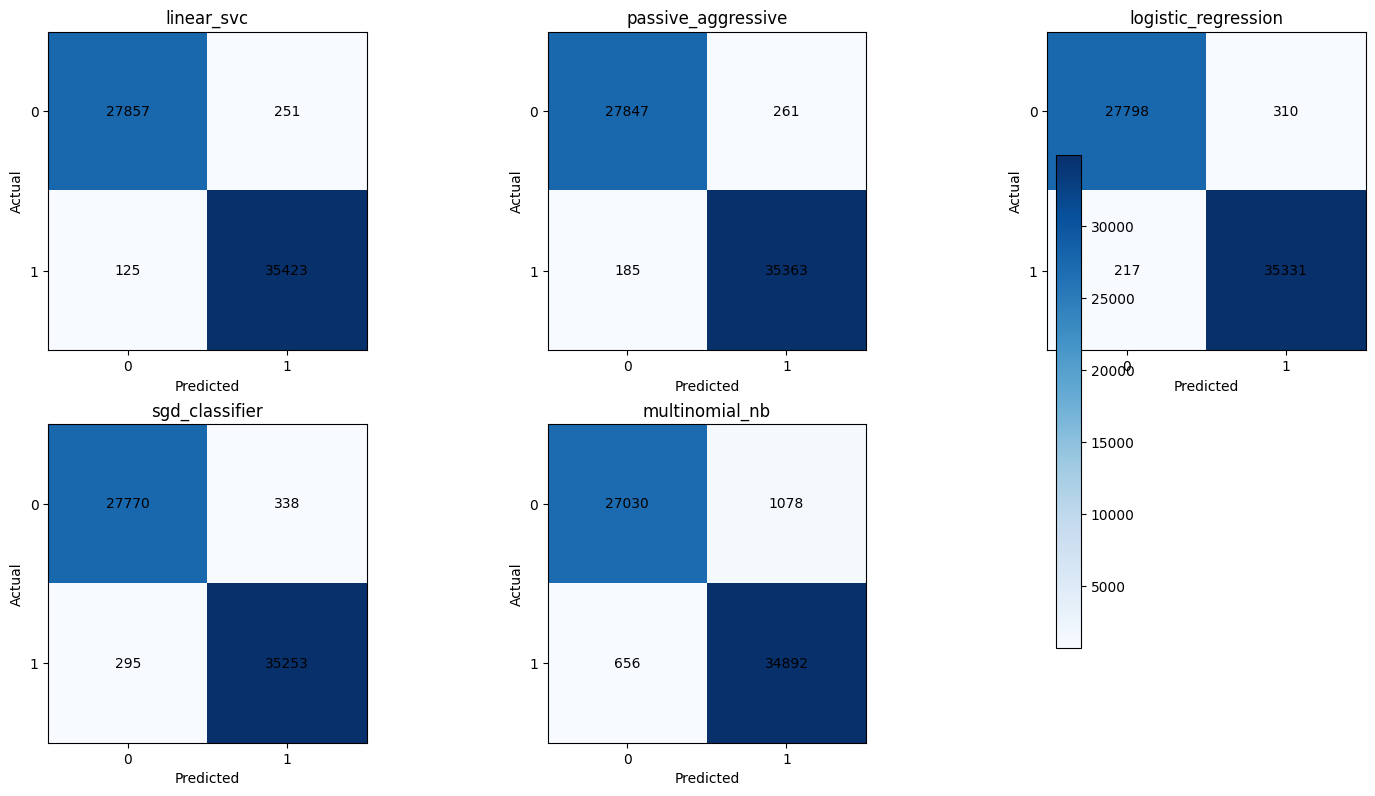

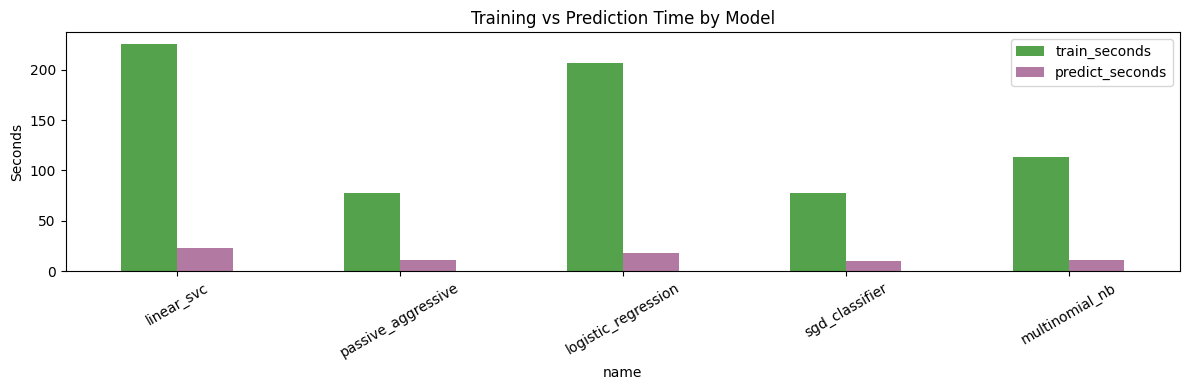

In [13]:
# Per-model confusion matrices
models_n = len(ranked_results)
cols = 3
rows = (models_n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, result in enumerate(ranked_results):
    cm = result['confusion_matrix']
    ax = axes[i]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(result['name'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1], labels=['0', '1'])
    ax.set_yticks([0, 1], labels=['0', '1'])

    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r][c], ha='center', va='center', color='black')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.colorbar(im, ax=axes.tolist(), shrink=0.8)
plt.tight_layout()
plt.show()

# Timing comparison
timing_df = comparison_df[['name', 'train_seconds', 'predict_seconds']].set_index('name')
ax = timing_df.plot(kind='bar', figsize=(12, 4), rot=30, color=['#54A24B', '#B279A2'])
ax.set_title('Training vs Prediction Time by Model')
ax.set_ylabel('Seconds')
plt.tight_layout()
plt.show()